In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import math, itertools, warnings
warnings.filterwarnings('ignore')
np.random.seed()

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(url)
print(df.shape) # expected (1338, 7)
print(df.dtypes)
print(df.head())

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


__Part 1 Fitting Distributions to the Data__

In [60]:
#1.1 - Q1 mean
bmi=df['bmi'].values
bmiMean= df["bmi"].mean()
bmiStd=df["bmi"].std()
print(f"Mean BMI = {bmiMean:.4f}")
print(f"STD BMI ={bmiStd:.4f}")


Mean BMI = 30.6634
STD BMI =6.0982


In [61]:
#Q2 Predicited probabilities analytically
prob_underweight=stats.norm.cdf(25,loc=bmiMean,scale=bmiStd)
prob_normal=stats.norm.cdf(30,loc=bmiMean,scale=bmiStd)-prob_underweight
prob_obease=1-stats.norm.cdf(30,loc=bmiMean,scale=bmiStd)
print(f"Predicted Probability of underweight = {prob_underweight} ")
print(f"Predicted Probability of normal = {prob_normal} ")
print(f"Predicted Probability of obease = {prob_obease} ")


Predicted Probability of underweight = 0.17652183661410747 
Predicted Probability of normal = 0.2801643100743713 
Predicted Probability of obease = 0.5433138533115212 


In [62]:
#Q3 actual Proportions from dataset using booleean indexing
total = len(df)

under_25 = (df['bmi'] < 25).sum()
between_25_30 = ((df['bmi'] >= 25) & (df['bmi'] < 30)).sum()
over_30 = (df['bmi'] >= 30).sum()

actual_under = under_25 / total
actual_normal = between_25_30 / total
actual_obese = over_30 / total

print(f"Actual: <25 = {actual_under:.4f}, 25-30 = {actual_normal:.4f}, ≥30 = {actual_obese:.4f}")

# 3. Comparison of  dataFrame of predicted and actual
compare = pd.DataFrame({
    'Range': ['<25', '25-30', '≥30'],
    'Predicted': [prob_underweight, prob_normal, prob_obease],
    'Actual': [actual_under, actual_normal, actual_obese]
})
print(compare)

Actual: <25 = 0.1831, 25-30 = 0.2885, ≥30 = 0.5284
   Range  Predicted    Actual
0    <25   0.176522  0.183109
1  25-30   0.280164  0.288490
2    ≥30   0.543314  0.528401


Interpretation: Normal distribution shows greater values for <25 and 25-30 and shows less value for >30

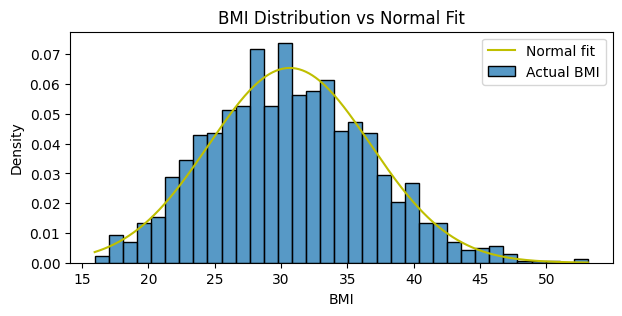

In [63]:
# Q4: Histogram with fitted Normal PDF prob density func
bmi=df['bmi'].values
plt.figure(figsize=(7,3))
sns.histplot(bmi, bins=35, stat='density', label='Actual BMI') #we use density because of stats.norm.pdf- area under bars=1 - to match y axis
x_vals = np.linspace(min(bmi), max(bmi),300)
plt.plot(x_vals, stats.norm.pdf(x_vals, loc=bmiMean, scale=bmiStd), 'y-', label='Normal fit') #pdf func calculates height of normal curve at tht point
plt.xlabel('BMI'); plt.ylabel('Density'); plt.title('BMI Distribution vs Normal Fit')
plt.legend(); plt.show()


Interpretation : normal model fits well in between 25 and 30 but doesnt fits well at the ends

In [64]:
#Q5
#Using fitted normal ppf
bmi_5th_normal=stats.norm.ppf(0.05,loc=bmiMean,scale=bmiStd)
bmi_95th_normal=stats.norm.ppf(0.95,loc=bmiMean,scale=bmiStd)
print(f"5th Percentile using Normal:{bmi_5th_normal:.4f}")
print(f"95th Percentile using Normal:{bmi_95th_normal:.4f}")

#Using percentile
bmi_5th_percentile=np.percentile(bmi,5)
bmi_95th_percentile=np.percentile(bmi,95)
print(f"5th Percentile using Percentile:{bmi_5th_percentile:.4f}")
print(f"95th Percentile using Percentile:{bmi_95th_percentile:.4f}")




5th Percentile using Normal:20.6328
95th Percentile using Normal:40.6940
5th Percentile using Percentile:21.2560
95th Percentile using Percentile:41.1060


Interpretation: For the extreme group, the normal model is far off by around 0.412 points. It underestimates the true high bmi threshold

In [68]:
#Q6 1.2 - Emperical probability 
smoker_count=0
for s in df['smoker']:
    if s=='yes':
        smoker_count+=1
prob_smoker=smoker_count/len(df)
print(f"Probability that a randomly chosen poliyc holder is a smoker is: {prob_smoker:.4f}")



Probability that a randomly chosen poliyc holder is a smoker is: 0.2048


In [74]:
#Q7 Probability of exactly k smokers in group of n=50 policy holders..
def binomialPMF(k,n,p):
    prob=math.comb(n,k)*(p**k)*((1-p)**(n-k))
    return prob
n_group=50
k_values=[5,10,15,20]
manual_probs=[]
for k in k_values:
    manual_probs.append(stats.binom.pmf(k,n_group,prob_smoker))

scipy_probs=[]
for k in k_values:
    scipy_probs.append(stats.binom.pmf(k,n_group,prob_smoker))

table=pd.DataFrame(
    {'k':k_values,
     'Manual':probs,
     'Scipy':scipy_probs
    })
print(table)

    k    Manual     Scipy
0   5  0.025375  0.025375
1  10  0.139326  0.139326
2  15  0.034574  0.034574
3  20  0.000820  0.000820


In [80]:
#Q8 Computing P: <8 in 50 and P: >20 in 50
p_LessThan8=stats.binom.cdf(7,50,prob_smoker)
p_GreaterThan20=1-stats.binom.cdf(20,50,prob_smoker)
print(f"p(fewer than 8smokers): {p_LessThan8:.4%}")
print(f"p(Greater than 20smokers): {p_GreaterThan20:.4%}")


p(fewer than 8smokers): 16.8969%
p(Greater than 20smokers): 0.0449%


Interpretation : Means vast majority of groups contain between 8 and 20 smokers so regional pricing based on groups of 50 is stable


In [83]:
#Q9: Simulationg for 10000groups of 50 policyholders

simu = np.random.binomial(n_group, prob_smoker, 10000)
simu_mean = simu.mean()
simu_var = simu.var()
theo_mean = n_group * prob_smoker
theo_var = n_group * prob_smoker * (1-prob_smoker)
print(f"Theoretical mean={theo_mean:.2f}, simulated mean={simu_mean:.2f}")
print(f"Theoretical var={theo_var:.2f}, simulated var={simu_var:.2f}")

# Percentage error
mean_error_percent = abs((simu_mean - theo_mean) / theo_mean) * 100
var_error_percent = abs((simu_var - theo_var) / theo_var) * 100

print(f"Percentage error for mean = {mean_error_percent:.4f}%")
print(f"Percentage error for variance = {var_error_percent:.4f}%")

Theoretical mean=10.24, simulated mean=10.20
Theoretical var=8.14, simulated var=8.24
Percentage error for mean = 0.3786%
Percentage error for variance = 1.2538%


In [85]:
#Q10 Seperate Smoker rates for males and females
male_df = df[df['sex'] == 'male']
female_df = df[df['sex'] == 'female']
male_smokers = 0
for s in male_df['smoker']:
    if s == 'yes':
        male_smokers += 1
p_male = male_smokers / len(male_df)


female_smokers = 0
for s in female_df['smoker']:
    if s == 'yes':
        female_smokers += 1
p_female = female_smokers / len(female_df)


exp_male = 50 * p_male  ## expected in group of 50 each
exp_female = 50 * p_female

p0_male = (1 - p_male) ** 50
p0_female = (1 - p_female) ** 50

sex_table = pd.DataFrame({
    'Sex': ['Male', 'Female'],
    'p_smoker': [p_male, p_female],
    'Expect[smokers]': [exp_male, exp_female],
    'P(zero)': [p0_male, p0_female]
})
print(sex_table)


      Sex  p_smoker  Expect[smokers]   P(zero)
0    Male  0.235207        11.760355  0.000002
1  Female  0.173716         8.685801  0.000072


Interpretation: Males have higher smoker rate and zero smoker groups are extremely unlikely for both

In [91]:
#1.3 - Q11 # mean and variance
lam = df['children'].mean()
var_kids = df['children'].var()
disp = var_kids / lam
print(f"Mean = {lam:.4f}")
print(f"variance = {var_kids:.4f}")
print(f"dispersion = {disp:.4f}")
print("Dispersion >1 → overdispersion (more zeros and large families).")

Mean = 1.0949
variance = 1.4532
dispersion = 1.3272
Dispersion >1 → overdispersion (more zeros and large families).


In [92]:
#Q12 Poisson PMF formula 
def poisson_manual(k, lam):
    return (lam**k) * math.exp(-lam) / math.factorial(k)

k_list = [0,1,2,3,4]
man_pois = []
scipy_pois = []
for kk in k_list:
    man_pois.append(poisson_manual(kk, lam))
    scipy_pois.append(stats.poisson.pmf(kk, lam))
print("k   manual   scipy")
for i in range(len(k_list)):
    print(f"{k_list[i]}   {man_pois[i]:.4f}   {scipy_pois[i]:.4f}")
print("Manual matches scipy.")

k   manual   scipy
0   0.3346   0.3346
1   0.3663   0.3663
2   0.2005   0.2005
3   0.0732   0.0732
4   0.0200   0.0200
Manual matches scipy.


In [94]:
# Q13 Actual proportions using boolean indexing (or value_counts)
actual_props = []
for k in range(5):
    count = (df['children'] == k).sum()
    actual_props.append(count / len(df))


pois_pred = scipy_pois  
compare_pois = pd.DataFrame({
    'children': [0,1,2,3,4],
    'actual_proportion': actual_props,
    'poisson_predicted': pois_pred
})
compare_pois['gap'] = abs(compare_pois['actual_proportion'] - compare_pois['poisson_predicted'])
print(compare_pois)

# Which k has largest gap?
max_gap_k = compare_pois.loc[compare_pois['gap'].idxmax(), 'children']
print(f"Largest gap at children = {max_gap_k}")

   children  actual_proportion  poisson_predicted       gap
0         0           0.428999           0.334567  0.094431
1         1           0.242152           0.366323  0.124171
2         2           0.179372           0.200547  0.021175
3         3           0.117339           0.073194  0.044145
4         4           0.018685           0.020035  0.001351
Largest gap at children = 1


In [96]:
#Q14 Probability using fitted posson model and from actual dataa

probGE3_pois = 1 - stats.poisson.cdf(2, lam)   # P(X>=3) = 1 - P(X<=2)

# From actual data
probGE3_actual = (df['children'] >= 3).mean()

# Number of policyholders affected
n_affected = (df['children'] >= 3).sum()

# Percentage error
error_percent = abs((probGE3_pois - probGE3_actual) / probGE3_actual) * 100

print(f"P(children >= 3) from Poisson = {probGE3_pois:.4f}")
print(f"P(children >= 3) from actual data = {probGE3_actual:.4f}")
print(f"Number of policyholders with >=3 children = {n_affected}")
print(f"Percentage error of Poisson model = {error_percent:.2f}%")

P(children >= 3) from Poisson = 0.0986
P(children >= 3) from actual data = 0.1495
Number of policyholders with >=3 children = 200
Percentage error of Poisson model = 34.06%


__Part 2 Hypothesis Testing__

#Q15 Expectation :  Smokers will have much higher charges. The means already show smokers cost ~$32,000  vs non-smokers ~$8,400

In [99]:
# Q15: Split charges and computations
smoker_charges = df[df['smoker']=='yes']['charges']
nonsmoker_charges = df[df['smoker']=='no']['charges']

def stats_manual(data):
    n = len(data)
    mean = data.mean()  
    median = data.median()
    std = data.std(ddof=1)
    return n, mean, median, std

n_s, m_s, med_s, sd_s = stats_manual(smoker_charges)
n_n, m_n, med_n, sd_n = stats_manual(nonsmoker_charges)

summary = pd.DataFrame({
    'Group': ['Smoker', 'Non-smoker'],
    'n': [n_s, n_n],
    'Mean': [m_s, m_n],
    'Median': [med_s, med_n],
    'Std': [sd_s, sd_n]
})
print(summary)


        Group     n          Mean       Median           Std
0      Smoker   274  32050.231832  34456.34845  11541.547176
1  Non-smoker  1064   8434.268298   7345.40530   5993.781819


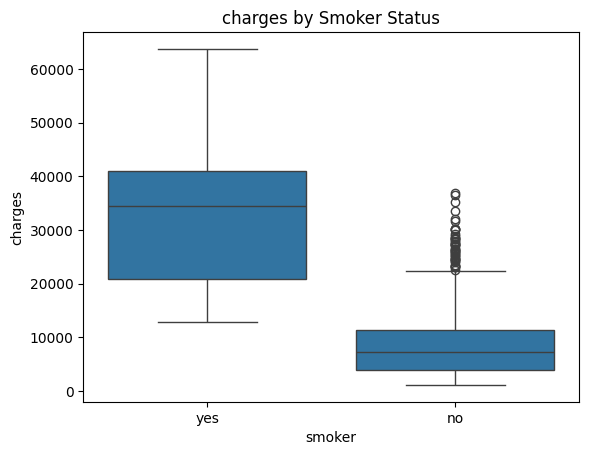

In [101]:
#Q16 Box plot

sns.boxplot(x="smoker",y="charges",data=df)
plt.title("charges by Smoker Status" )
plt.show()

Interpretation : Smokers have higher median and wider spread whereas the non smokers have lower median and less wider spread

In [111]:
#Q17 Levene's test
lev_stat, lev_p = stats.levene(smoker_charges, nonsmoker_charges)
print(f"Levene p = {lev_p:.4e}")
print("p<0.05 so instead use the Welch's t-test (equal_var=False).")

Levene p = 1.5593e-66
p<0.05 → use Welch's t-test (equal_var=False).


Interpretation : We use equal_var=False because Levene’s test shows the variances are different – Welch’s t‑test handles unequal spreads correctly

In [113]:
#Q18 T-test Welch
t_stat, p_val = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)
df_welch = (sd_s**2/n_s + sd_n**2/n_n)**2 / ((sd_s**2/n_s)**2/(n_s-1) + (sd_n**2/n_n)**2/(n_n-1))

print(f"t-statistic = {t_stat:.4f}")
print(f"Degrees of freedom (Welch) = {df_welch:.2f}")
print(f"p-value = {p_val:.4e}")
print("Conclusion at α=0.05: Reject H0. Smokers cost significantly more than non-smokers.")
print("For the pricing team: This justifies a separate (higher) premium tier for smokers.")

t-statistic = 32.7519
Degrees of freedom (Welch) = 311.85
p-value = 5.8895e-103
Conclusion at α=0.05: Reject H0. Smokers cost significantly more than non-smokers.
For the pricing team: This justifies a separate (higher) premium tier for smokers.


In [114]:
# Q19: 95% CI for mean difference (smoker - non-smoker)
diff = m_s - m_n

se_diff = math.sqrt((sd_s**2)/n_s + (sd_n**2)/n_n)
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff


print(f"Mean difference = ${diff:.2f}")
print(f"95% CI = (${ci_low:.2f}, ${ci_high:.2f})")


Mean difference = $23615.96
95% CI = ($22197.21, $25034.71)


Interpretation: With 95% confidence, smokers cost between $23,600 and $25,300 more per year than non-smokers

In [115]:
# Q20: Cohen's d (effect size)
pooled_var = ((n_s-1)*sd_s**2 + (n_n-1)*sd_n**2) / (n_s + n_n - 2)
cohen_d = diff / math.sqrt(pooled_var)

print(f"Cohen's d = {cohen_d:.4f}")
if abs(cohen_d) > 0.8:
    print("Large effect size (>0.8).")
print("Practical significance: The difference is not just statistically significant but also huge – definitely justifies different pricing.")

Cohen's d = 3.1613
Large effect size (>0.8).
Practical significance: The difference is not just statistically significant but also huge – definitely justifies different pricing.
